In [6]:
import os
import copy
import pickle
import sympy
import functools
import itertools
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from error_injection import MissingValueError, SamplingError, Injector
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.metrics import mutual_info_score, auc, roc_curve, roc_auc_score, f1_score
from scipy.optimize import minimize as scipy_min
from scipy.spatial import ConvexHull
from scipy.optimize import minimize, Bounds, linprog
from sympy import Symbol as sb
from sympy import lambdify
from tqdm.notebook import trange,tqdm
from IPython.display import display,clear_output
from random import choice
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import _tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score
from itertools import combinations, product
import heapq
class style():
    RED = '\033[31m'
    GREEN = '\033[32m'
    BLUE = '\033[34m'
    RESET = '\033[0m'

np.random.seed(1)

# ignore all the warnings
import warnings
warnings.filterwarnings('ignore')

In [7]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
boston_df = pd.read_csv('housing.csv', header=None, delimiter=r"\s+", names=column_names)
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [8]:
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [9]:
X = boston_df.drop(columns=['MEDV'])
y = boston_df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train, X_test, y_train, y_test = X_train.reset_index(drop=True), X_test.reset_index(drop=True), y_train.reset_index(drop=True), y_test.reset_index(drop=True)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (404, 13)
Testing data shape: (102, 13)


In [10]:
y_train

0      25.3
1      23.3
2       7.2
3      21.2
4      11.7
       ... 
399    20.9
400    22.8
401    12.5
402    24.0
403    21.0
Name: MEDV, Length: 404, dtype: float64

In [11]:
#Useful functions
symbol_id = -1
def create_symbol(suffix=''):
    global symbol_id
    symbol_id += 1
    name = f'e{symbol_id}_{suffix}' if suffix else f'e{symbol_id}'
    return sympy.Symbol(name=name)


scaler_symbols = set([sb(f'k{i}') for i in range(X_train.shape[1]+1)])
linearization_dict = dict()
reverse_linearization_dict = dict()

def inject_sensitive_ranges(X, y, uncertain_attr, uncertain_num, boundary_indices, uncertain_radius_pct=None, 
                  uncertain_radius=None, seed=42):
    global symbol_id
    symbol_id = -1
    
    X_extended = np.append(np.ones((len(X), 1)), X, axis=1)
    ss = StandardScaler()
    X_extended[:, 1:] = ss.fit_transform(X_extended[:, 1:])
    X_extended_symb = sympy.Matrix(X_extended)
    
    if not(uncertain_attr=='y'):
        uncertain_attr_idx = X.columns.to_list().index(uncertain_attr) + 1
        if not(uncertain_radius):
            uncertain_radius = uncertain_radius_pct*(np.max(X_extended[:, uncertain_attr_idx])-\
                                                     np.min(X_extended[:, uncertain_attr_idx]))
    else:
        if not(uncertain_radius):
            uncertain_radius = uncertain_radius_pct*(y_train.max()-y_train.min())[0] #not error with subscription? due to float created? uncertain
    
    np.random.seed(seed)
    uncertain_indices = boundary_indices[:uncertain_num]
    y_symb = sympy.Matrix(y)
    symbols_in_data = set()
    #print(uncertain_indices)
    for uncertain_idx in uncertain_indices:
        new_symb = create_symbol()
        symbols_in_data.add(new_symb)
        if uncertain_attr=='y':
            y_symb[uncertain_idx] = y_symb[uncertain_idx] + uncertain_radius*new_symb
        else:
            X_extended_symb[uncertain_idx, uncertain_attr_idx] = X_extended_symb[uncertain_idx, uncertain_attr_idx] + uncertain_radius*new_symb
    return X_extended_symb, y_symb, symbols_in_data, ss

# if interval=True, use interval arithmetic, otherwise use zonotopes
def compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, robustness_radius,
                                         uncertain_num, boundary_indices, uncertain_radius=None, 
                                         lr=0.1, seed=42, interval=True):
    X, y, symbols_in_data, ss = inject_sensitive_ranges(X=X_train, y=y_train, uncertain_attr='y', 
                                              uncertain_num=uncertain_num, boundary_indices=boundary_indices, 
                                              uncertain_radius=uncertain_radius, 
                                              uncertain_radius_pct=None, seed=seed)
    
    assert len(X.free_symbols)==0
    # closed-form
    param = (X.T*X).inv()*X.T*y
    
    if interval:
        # make param intervals
        for d in range(len(param)):
            expr = param[d]
            if not(expr.free_symbols):
                continue
            else:
                constant_part = 0
                interval_radius = 0
                for arg in expr.args:
                    if arg.free_symbols:
                        interval_radius += abs(arg.args[0])
                    else:
                        assert constant_part == 0
                        constant_part = arg
                param[d] = constant_part + create_symbol()*interval_radius
    
    test_preds = sympy.Matrix(np.append(np.ones((len(X_test), 1)), ss.transform(X_test), axis=1))*param
    robustness_ls = []
    for pred in test_preds:
        pred_range_radius = 0
        for arg in pred.args:
            if arg.free_symbols:
                pred_range_radius += abs(arg.args[0])
        if pred_range_radius <= robustness_radius:
            robustness_ls.append(1)
        else:
            robustness_ls.append(0)
    
#     print(param)
    return np.mean(robustness_ls)

def inject_ranges(X, y, uncertain_attr, uncertain_num, uncertain_radius_pct=None, uncertain_radius=None, seed=42):
    global symbol_id
    symbol_id = -1
    
    X_extended = np.append(np.ones((len(X), 1)), X, axis=1)
    ss = StandardScaler()
    X_extended[:, 1:] = ss.fit_transform(X_extended[:, 1:])
    X_extended_symb = sympy.Matrix(X_extended)
    
    if not(uncertain_attr=='y'):
        uncertain_attr_idx = X.columns.to_list().index(uncertain_attr) + 1
        if not(uncertain_radius):
            uncertain_radius = uncertain_radius_pct*(np.max(X_extended[:, uncertain_attr_idx])-\
                                                     np.min(X_extended[:, uncertain_attr_idx]))
    else:
        if not(uncertain_radius):
            uncertain_radius = uncertain_radius_pct*(y_train.max()-y_train.min())[0] #not error with subscription? due to float created? uncertain
    
    np.random.seed(seed)
    uncertain_indices = np.random.choice(range(len(y)), uncertain_num, replace=False)
    y_symb = sympy.Matrix(y)
    symbols_in_data = set()
    for uncertain_idx in uncertain_indices:
        new_symb = create_symbol()
        symbols_in_data.add(new_symb)
        if uncertain_attr=='y':
            y_symb[uncertain_idx] = y_symb[uncertain_idx] + uncertain_radius*new_symb
        else:
            X_extended_symb[uncertain_idx, uncertain_attr_idx] = X_extended_symb[uncertain_idx, uncertain_attr_idx] + uncertain_radius*new_symb
    return X_extended_symb, y_symb, symbols_in_data, ss

# if interval=True, use interval arithmetic, otherwise use zonotopes
def compute_robustness_ratio_label_error(X_train, y_train, X_test, y_test, robustness_radius,
                                         uncertain_num, uncertain_radius=None, 
                                         lr=0.1, seed=42, interval=True):
    X, y, symbols_in_data, ss = inject_ranges(X=X_train, y=y_train, uncertain_attr='y', 
                                              uncertain_num=uncertain_num, uncertain_radius=uncertain_radius, 
                                              uncertain_radius_pct=None, seed=seed)
    
    assert len(X.free_symbols)==0
    # closed-form
    param = (X.T*X).inv()*X.T*y
    
    if interval:
        # make param intervals
        for d in range(len(param)):
            expr = param[d]
            if not(expr.free_symbols):
                continue
            else:
                constant_part = 0
                interval_radius = 0
                for arg in expr.args:
                    if arg.free_symbols:
                        interval_radius += abs(arg.args[0])
                    else:
                        assert constant_part == 0
                        constant_part = arg
                param[d] = constant_part + create_symbol()*interval_radius
    
    test_preds = sympy.Matrix(np.append(np.ones((len(X_test), 1)), ss.transform(X_test), axis=1))*param
    robustness_ls = []
    for pred in test_preds:
        pred_range_radius = 0
        for arg in pred.args:
            if arg.free_symbols:
                pred_range_radius += abs(arg.args[0])
        if pred_range_radius <= robustness_radius:
            robustness_ls.append(1)
        else:
            robustness_ls.append(0)
    
#     print(param)
    return np.mean(robustness_ls)

In [12]:
not 1

False

In [13]:
for i in X_train.columns:
    print(i, len(X_train[i].unique()))

CRIM 402
ZN 25
INDUS 72
CHAS 2
NOX 76
RM 366
AGE 302
DIS 339
RAD 9
TAX 63
PTRATIO 46
B 287
LSTAT 366


In [14]:
y_train

0      25.3
1      23.3
2       7.2
3      21.2
4      11.7
       ... 
399    20.9
400    22.8
401    12.5
402    24.0
403    21.0
Name: MEDV, Length: 404, dtype: float64

In [15]:
X_train_transformed = X_train.copy()
X_test_transformed = X_test.copy()

columns_to_bin = ['CRIM', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'B', 'LSTAT']
n_bins = {'CRIM': int(np.sqrt(402)), 'INDUS': int(np.sqrt(72)), 'NOX': int(np.sqrt(76)), 'RM': int(np.sqrt(366)), 'AGE': int(np.sqrt(302)), 'DIS': int(np.sqrt(339)), 'B': int(np.sqrt(287)), 'LSTAT': int(np.sqrt(366))}
column_bins = {}

for col in columns_to_bin:
    # Apply binning (equal-width bins in this example)
    X_train_transformed[col], bins = pd.cut(
        X_train[col], 
        bins=n_bins[col], 
        labels=False, 
        retbins=True
    )

    X_test_transformed[col] = pd.cut(
        X_test[col],
        bins=bins,      # Use the same bins from X_train
        labels=False,   # Keep consistent labels
        include_lowest=True  # Ensure the lowest bin includes its boundary
    )

    X_train_transformed[col] = X_train_transformed[col].fillna(-1).astype(int)
    X_test_transformed[col] = X_test_transformed[col].fillna(-1).astype(int)

    column_bins[col] = bins

In [16]:
corr = abs(X_train.corrwith(y_train)).sort_values(ascending=False)
corr.index[0:5].tolist()

['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX']

In [17]:
#X_train_transformed = X_train_transformed[corr.index[0:5].tolist()]
#X_test_transformed = X_test_transformed[corr.index[0:5].tolist()]
#X_train_transformed = X_train_transformed[['LSTAT', 'RM', 'PTRATIO', 'DIS', 'TAX']]
#X_test_transformed = X_test_transformed[['LSTAT', 'RM', 'PTRATIO', 'DIS', 'TAX']]
X_train_transformed.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0,0.0,1,0,1,9,0,7,3,233.0,17.9,15,2
1,0,25.0,1,0,1,9,4,10,8,284.0,19.7,15,2
2,3,0.0,5,0,5,6,16,0,24,666.0,20.2,15,15
3,0,0.0,3,0,0,9,8,6,5,398.0,18.7,15,5
4,1,0.0,5,0,3,7,11,1,24,666.0,20.2,0,8


# Instructions
1. Initiate all cells above
2. Don't run any cells below except the "get_complex_candidate_target_indices" function
3. Run all cells and below starting from cell after "result" variable

In [18]:
def compute_optimized_candidates(X, tau, n_features_to_combine=2):

    candidates = []
    n_samples, n_features = X.shape
    
    # Generate combinations of features to combine
    feature_combinations = list(combinations(range(n_features), n_features_to_combine))
    
    for feature_combo in tqdm(feature_combinations, desc="Processing feature combinations"):
        # Get unique values for each feature in the combination
        values_list = [np.unique(X.iloc[:, idx]) for idx in feature_combo]
        
        # Iterate over all possible value-condition combinations
        for value_combo in tqdm(
            product(*values_list),
            desc=f"Processing combination {feature_combo}",
            leave=False
        ):
            for conditions in product(["<", "=", ">"], repeat=n_features_to_combine):
                # Skip conflicting combinations
                if has_conflicts(value_combo, conditions):
                    continue

                # Generate pattern
                pattern = np.ones(n_samples, dtype=bool)  # Start with all True
                for idx, (feat_idx, val, cond) in enumerate(zip(feature_combo, value_combo, conditions)):
                    if cond == "<":
                        pattern &= X.iloc[:, feat_idx] < val
                    elif cond == "=":
                        pattern &= X.iloc[:, feat_idx] == val
                    elif cond == ">":
                        pattern &= X.iloc[:, feat_idx] > val
                
                # Check support
                support = np.sum(pattern)
                if support <= (tau * n_samples): #and support >= (0.5 * tau * n_samples):
                    candidates.append((feature_combo, value_combo, conditions))
    
    return candidates


def has_conflicts(value_combo, conditions):
    for i in range(len(value_combo)):
        for j in range(i + 1, len(value_combo)):
            # Detect conflicts like "< x AND > x" for the same value
            if conditions[i] == ">" and conditions[j] == "<" and value_combo[i] <= value_combo[j]:
                return True
            if conditions[i] == "<" and conditions[j] == ">" and value_combo[i] >= value_combo[j]:
                return True
            # Detect conflicts like "= x AND < x" or "= x AND > x"
            if conditions[i] == "=" and (conditions[j] == "<" and value_combo[i] >= value_combo[j]):
                return True
            if conditions[i] == "=" and (conditions[j] == ">" and value_combo[i] <= value_combo[j]):
                return True
            # Symmetry of conditions
            if conditions[j] == "=" and (conditions[i] == "<" and value_combo[j] >= value_combo[i]):
                return True
            if conditions[j] == "=" and (conditions[i] == ">" and value_combo[j] <= value_combo[i]):
                return True
    return False

In [19]:
candidates = compute_optimized_candidates(X_train_transformed, 0.1, n_features_to_combine=2)
len(candidates)

Processing feature combinations:   0%|          | 0/78 [00:00<?, ?it/s]

Processing combination (0, 1): 0it [00:00, ?it/s]

Processing combination (0, 2): 0it [00:00, ?it/s]

Processing combination (0, 3): 0it [00:00, ?it/s]

Processing combination (0, 4): 0it [00:00, ?it/s]

...

Processing combination (9, 12): 0it [00:00, ?it/s]

Processing combination (10, 11): 0it [00:00, ?it/s]

Processing combination (10, 12): 0it [00:00, ?it/s]

Processing combination (11, 12): 0it [00:00, ?it/s]

130871

In [20]:
def get_complex_candidate_target_indices(df, candidate):
    columns, values, conditions = candidate
    mask = pd.Series(True, index=df.index)  # Start with a mask that selects all rows

    for col, val, cond in zip(columns, values, conditions):
        if cond == "<":
            mask &= df.iloc[:, col] < val
        elif cond == "=":
            mask &= df.iloc[:, col] == val
        elif cond == ">":
            mask &= df.iloc[:, col] > val
        else:
            raise ValueError(f"Unsupported condition: {cond}")

    return df[mask].index.tolist()

In [21]:
def filter_dataframe_by_complex_candidate(df, labels, candidate):
    mask = get_complex_candidate_target_indices(df, candidate)

    return df[df.index.isin(mask) == False], labels[labels.index.isin(mask) == False]

In [23]:
def mse(y_true, y_pred):
    return sum((y_true - y_pred)**2)/len(y_true)

def mae(y_true, y_pred):
    return sum(abs(y_true - y_pred))/len(y_true)

lr = LinearRegression()

def mse_filter(candidates, X_train_transformed, X_test_transformed, y_train, y_test):

    top_candidates = []

    seen_mse = set()
    
    for candidate in tqdm(candidates, desc="Processing Candidates"):
        number_indices = len(get_complex_candidate_target_indices(X_train_transformed, candidate))
        filtered_X_train, filtered_y_train = filter_dataframe_by_complex_candidate(X_train_transformed, y_train, candidate)
        model = lr.fit(filtered_X_train, filtered_y_train)
        predictions = model.predict(X_test_transformed)
        #print(predictions)
        new_mse = mse(predictions, y_test)
        #print(new_mae)

        if new_mse in seen_mse:
            continue
        
        seen_mse.add(new_mse)

        top_candidates = top_candidates + [(new_mse, candidate, number_indices)]
    top_candidates = sorted(top_candidates, key=lambda x: (x[0], -x[2]), reverse=True)[0:3000]
    return top_candidates

In [24]:
top_candidates = [x[1] for x in mse_filter(candidates, X_train_transformed, X_test_transformed, y_train, y_test)]
len(top_candidates)

Processing Candidates:   0%|          | 0/130871 [00:00<?, ?it/s]

3000

In [25]:
def top_k_finder(candidates, X_transformed, X_train, y_train, X_test, y_test, k, tau, robustness_radius, uncertain_ratio):
    n_samples, n_features = X_train.shape

    seen_ratios = set()
    
    # Min-heap to store the top k worst robustness ratios
    top_k_patterns = []
    
    for candidate in tqdm(candidates, desc="Processing Candidates"):
        # Get indices satisfying the candidate pattern
        target_indices = get_complex_candidate_target_indices(X_transformed, candidate)
        
        # Compute robustness ratio
        robustness_ratio = compute_robustness_ratio_sensitive_label_error(
            X_train, y_train, X_test, y_test, 
            uncertain_num=int(tau * len(y_train)),
            boundary_indices=target_indices,
            uncertain_radius=uncertain_ratio * (y_train.max() - y_train.min()), 
            robustness_radius=robustness_radius, 
            interval=False
        )

        if robustness_ratio in seen_ratios:
            continue

        seen_ratios.add(robustness_ratio)
        
        print(robustness_ratio)
        
        top_k_patterns = top_k_patterns + [(robustness_ratio, candidate)]
        
    return sorted(top_k_patterns, key=lambda x: x[0])[0:k]

In [ ]:
result = top_k_finder(top_candidates, X_train_transformed, X_train, y_train, X_test, y_test, 10, 0.1, 2, 0.25)

Processing Candidates:   0%|          | 0/3000 [00:00<?, ?it/s]

0.5588235294117647
0.21568627450980393
0.3431372549019608
0.5392156862745098
0.5784313725490197
0.2549019607843137
0.29411764705882354
0.2647058823529412
0.4803921568627451
0.6176470588235294
0.6372549019607843
0.5882352941176471
0.38235294117647056
0.4019607843137255
0.30392156862745096
0.27450980392156865
0.6568627450980392
0.23529411764705882
0.5980392156862745
0.7647058823529411
0.6666666666666666
0.6470588235294118
0.4117647058823529
0.24509803921568626
0.3235294117647059
0.7745098039215687
0.7450980392156863
0.7941176470588235
0.6764705882352942
0.7549019607843137
0.22549019607843138
0.5
0.7843137254901961
0.7058823529411765
0.6078431372549019
0.28431372549019607
0.7254901960784313
0.3137254901960784
0.803921568627451
0.8137254901960784
0.45098039215686275
0.8235294117647058
0.8333333333333334
0.5490196078431373
0.696078431372549
0.5098039215686274
0.35294117647058826
0.5196078431372549
0.37254901960784315
0.9117647058823529
0.6862745098039216
0.4215686274509804
0.735294117647058

In [ ]:
result

In [ ]:
[(0.08823529411764706, ((5, 10), (10, 17.9), ('>', '>'))),
 (0.11764705882352941, ((7, 12), (3, 5), ('<', '<'))),
 (0.13725490196078433, ((9, 12), (398.0, 6), ('>', '<')))]

In [14]:
pattern1 =  ((5, 10), (10, 17.9), ('>', '>'))
pattern2 = ((7, 12), (3, 5), ('<', '<'))
pattern3 = ((9, 12), (398.0, 6), ('>', '<'))
#pattern1 =  ((5, 9), (7, 437.0), ('<', '>'))
#pattern2 = ((0, 4), (0, 4), ('>', '='))
#pattern3 = ((6, 8), (15, 8), ('=', '>'))

target_indices_of_pattern1 = get_complex_candidate_target_indices(X_train_transformed, pattern1)
target_indices_of_pattern2 = get_complex_candidate_target_indices(X_train_transformed, pattern2)
target_indices_of_pattern3 = get_complex_candidate_target_indices(X_train_transformed, pattern3)

In [15]:
cols = X_train.columns
print("Pattern 1:")
for i in range(0, len(pattern1[0])):
    target_column = cols[pattern1[0][i]]
    val = pattern1[1][i]
    condition = pattern1[2][i]
    if target_column in column_bins:
        binnings = column_bins[target_column]
        if condition == '>':
            val = binnings[val]
            print(f"'{target_column}' {condition} {val}")
        elif condition == '<':
            val = binnings[val - 1]
            print(f"'{target_column}' {condition} {val}")
        else:
            lower_val = binnings[val - 1]
            upper_val = binnings[val]
            print(f"{lower_val} < '{target_column}' < {upper_val}")
    else:
        print(f"'{target_column}' {condition} {val}")
print()
print("Pattern 2:")
for i in range(0, len(pattern2[0])):
    target_column = cols[pattern2[0][i]]
    val = pattern2[1][i]
    condition = pattern2[2][i]
    if target_column in column_bins:
        binnings = column_bins[target_column]
        if condition == '>':
            val = binnings[val]
            print(f"'{target_column}' {condition} {val}")
        elif condition == '<':
            val = binnings[val - 1]
            print(f"'{target_column}' {condition} {val}")
        else:
            lower_val = binnings[val - 1]
            upper_val = binnings[val]
            print(f"{lower_val} < '{target_column}' < {upper_val}")
    else:
        print(f"'{target_column}' {condition} {val}")
print()
print("Pattern 3:")
for i in range(0, len(pattern3[0])):
    target_column = cols[pattern3[0][i]]
    val = pattern3[1][i]
    condition = pattern3[2][i]
    if target_column in column_bins:
        binnings = column_bins[target_column]
        if condition == '>':
            val = binnings[val]
            print(f"'{target_column}' {condition} {val}")
        elif condition == '<':
            val = binnings[val - 1]
            print(f"'{target_column}' {condition} {val}")
        else:
            lower_val = binnings[val - 1]
            upper_val = binnings[val]
            print(f"{lower_val} < '{target_column}' < {upper_val}")
    else:
        print(f"'{target_column}' {condition} {val}")

Pattern 1:
'RM' > 6.307842105263157
'PTRATIO' > 17.9

Pattern 2:
'DIS' < 2.3514777777777778
'LSTAT' < 9.359473684210526

Pattern 3:
'TAX' > 398.0
'LSTAT' < 11.266842105263159


In [16]:
def matchcounter(x, y):
    count = 0
    
    for i in x:
        if i in y:
            count += 1
    return count
match_1_and_2 = matchcounter(target_indices_of_pattern1, target_indices_of_pattern2)
match_1_and_3 = matchcounter(target_indices_of_pattern1, target_indices_of_pattern3)
match_2_and_3 = matchcounter(target_indices_of_pattern2, target_indices_of_pattern3)
print(f"Overlapping target indices in patterns 1 and 2: {match_1_and_2}")
print(f"Overlapping target indices in patterns 1 and 3: {match_1_and_3}")
print(f"Overlapping target indices in patterns 2 and 3: {match_2_and_3}")

Overlapping target indices in patterns 1 and 2: 5
Overlapping target indices in patterns 1 and 3: 3
Overlapping target indices in patterns 2 and 3: 17


In [17]:
pattern1_df = X_train.loc[target_indices_of_pattern1]
pattern2_df = X_train.loc[target_indices_of_pattern2]
pattern3_df = X_train.loc[target_indices_of_pattern3]

def jaccard_similary(df1, df2, col):
    set1 = set(df1[col].values)
    set2 = set(df2[col].values)

    intersection = set1.intersection(set2)

    union = set1.union(set2)
    return len(intersection) / len(union)
print("Jaccard Similarities:")
print("")
print("Pattern 1 and Pattern 2")
print(f"RM: {jaccard_similary(pattern1_df, pattern2_df, 'RM')}")
print(f"TAX: {jaccard_similary(pattern1_df, pattern2_df, 'TAX')}")
print(f"CRIM: {jaccard_similary(pattern1_df, pattern2_df, 'CRIM')}")
print(f"NOX: {jaccard_similary(pattern1_df, pattern2_df, 'NOX')}")
print("")
print("Pattern 1 and Pattern 3")
print(f"RM: {jaccard_similary(pattern1_df, pattern3_df, 'RM')}")
print(f"TAX: {jaccard_similary(pattern1_df, pattern3_df, 'TAX')}")
print(f"RAD: {jaccard_similary(pattern1_df, pattern3_df, 'RAD')}")
print(f"AGE: {jaccard_similary(pattern1_df, pattern3_df, 'AGE')}")
print("")
print("Pattern 2 and Pattern 3")
print(f"CRIM: {jaccard_similary(pattern2_df, pattern3_df, 'CRIM')}")
print(f"NOX: {jaccard_similary(pattern2_df, pattern3_df, 'NOX')}")
print(f"RAD: {jaccard_similary(pattern2_df, pattern3_df, 'RAD')}")
print(f"AGE: {jaccard_similary(pattern2_df, pattern3_df, 'AGE')}")

Jaccard Similarities:

Pattern 1 and Pattern 2
RM: 0.07042253521126761
TAX: 0.15
CRIM: 0.0684931506849315
NOX: 0.1935483870967742

Pattern 1 and Pattern 3
RM: 0.04285714285714286
TAX: 0.05
RAD: 0.4444444444444444
AGE: 0.09375

Pattern 2 and Pattern 3
CRIM: 0.288135593220339
NOX: 0.3333333333333333
RAD: 0.5714285714285714
AGE: 0.2692307692307692


In [18]:
ratios = [0.0001, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

In [19]:
# pattern1_testing (Meyer)
robustness_ratio_range_pattern1_meyer = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())

    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pct = 0.1
    uncertain_num = int(uncertain_pct*len(y_train))
    for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):

        robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=target_indices_of_pattern1,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=True, seed=seed)
        robustness_ratio_range_pattern1_meyer = robustness_ratio_range_pattern1_meyer + [robustness_ratio]
robustness_ratio_range_pattern1_meyer

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

[1.0,
 0.13725490196078433,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [20]:
# pattern1_testing (Zorro)
robustness_ratio_range_pattern1_zorro = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())

    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pct = 0.1
    uncertain_num = int(uncertain_pct*len(y_train))
    for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
        
        robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=target_indices_of_pattern1,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=False, seed=seed)
        robustness_ratio_range_pattern1_zorro = robustness_ratio_range_pattern1_zorro + [robustness_ratio]
robustness_ratio_range_pattern1_zorro

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

[1.0,
 1.0,
 0.9313725490196079,
 0.6470588235294118,
 0.3137254901960784,
 0.08823529411764706,
 0.029411764705882353,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [21]:
# pattern2_testing (Meyer)
robustness_ratio_range_pattern2_meyer = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())

    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pct = 0.1
    uncertain_num = int(uncertain_pct*len(y_train))
    for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
        robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=target_indices_of_pattern2,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=True, seed=seed)
        robustness_ratio_range_pattern2_meyer = robustness_ratio_range_pattern2_meyer + [robustness_ratio]
robustness_ratio_range_pattern2_meyer

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

[1.0,
 0.08823529411764706,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [22]:
# pattern2_testing (Zorro)
robustness_ratio_range_pattern2_zorro = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())

    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pct = 0.1
    uncertain_num = int(uncertain_pct*len(y_train))
    for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
        robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=target_indices_of_pattern2,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=False, seed=seed)
        robustness_ratio_range_pattern2_zorro = robustness_ratio_range_pattern2_zorro + [robustness_ratio]
robustness_ratio_range_pattern2_zorro

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

[1.0,
 1.0,
 0.8725490196078431,
 0.6568627450980392,
 0.3627450980392157,
 0.11764705882352941,
 0.058823529411764705,
 0.029411764705882353,
 0.00980392156862745,
 0.0,
 0.0,
 0.0,
 0.0]

In [23]:
# pattern3_testing (Meyer)
robustness_ratio_range_pattern3_meyer = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())

    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pct = 0.1
    uncertain_num = int(uncertain_pct*len(y_train))
    for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
        robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=target_indices_of_pattern3,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=True, seed=seed)
        robustness_ratio_range_pattern3_meyer = robustness_ratio_range_pattern3_meyer + [robustness_ratio]
robustness_ratio_range_pattern3_meyer

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

[1.0,
 0.0784313725490196,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [24]:
# pattern3_testing (Zorro)
robustness_ratio_range_pattern3_zorro = []
for seed in range(1):
    # mpg +- 2 is robust
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())

    uncertain_radiuses = [ratio*label_range for ratio in ratios]
    uncertain_pct = 0.1
    uncertain_num = int(uncertain_pct*len(y_train))
    for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius'):
        robustness_ratio = compute_robustness_ratio_sensitive_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num,
                                                                    boundary_indices=target_indices_of_pattern3,
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=False, seed=seed)
        robustness_ratio_range_pattern3_zorro = robustness_ratio_range_pattern3_zorro + [robustness_ratio]
robustness_ratio_range_pattern3_zorro

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

[1.0,
 1.0,
 0.8725490196078431,
 0.6862745098039216,
 0.3431372549019608,
 0.13725490196078433,
 0.0784313725490196,
 0.049019607843137254,
 0.0196078431372549,
 0.00980392156862745,
 0.00980392156862745,
 0.0,
 0.0]

In [25]:
robustness_naive = np.zeros(len(ratios))
for seed in tqdm(range(5), desc=f'Progress'):
    placeholder = []
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())

    uncertain_pct = 0.1
    uncertain_num = int(uncertain_pct*len(y_train))
    for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius', leave=False):
        robustness_ratio = compute_robustness_ratio_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num, 
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=False, seed=seed)
        placeholder = placeholder + [robustness_ratio]
    robustness_naive = robustness_naive + np.array(placeholder)
robustness_naive = (robustness_naive/5).tolist()
robustness_naive

Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

[1.0,
 1.0,
 0.9705882352941178,
 0.7725490196078431,
 0.40980392156862744,
 0.16470588235294117,
 0.03529411764705882,
 0.011764705882352941,
 0.0058823529411764705,
 0.00196078431372549,
 0.0,
 0.0,
 0.0]

In [26]:
robustness_naive_interval = np.zeros(len(ratios))
for seed in tqdm(range(5), desc=f'Progress'):
    placeholder = []
    robustness_radius = 2
    label_range = (y_train.max()-y_train.min())

    uncertain_pct = 0.1
    uncertain_num = int(uncertain_pct*len(y_train))
    for uncertain_radius in tqdm(uncertain_radiuses, desc=f'Varying Uncertain Radius', leave=False):
        robustness_ratio = compute_robustness_ratio_label_error(X_train, y_train, X_test, y_test, 
                                                                    uncertain_num=uncertain_num, 
                                                                    uncertain_radius=uncertain_radius, 
                                                                    robustness_radius=robustness_radius, 
                                                                    interval=True, seed=seed)
        placeholder = placeholder + [robustness_ratio]
    robustness_naive_interval = robustness_naive_interval + np.array(placeholder)
robustness_naive_interval = (robustness_naive_interval/5).tolist()
robustness_naive_interval

Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

Varying Uncertain Radius:   0%|          | 0/13 [00:00<?, ?it/s]

[1.0,
 0.12941176470588234,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [33]:
ratios = [0.0001, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
def average_over_multiple_large_robustness_loss(robustness_lst, x):
    sum_vals = 0
    count = 0
    previous = -1
    for i in range(0, len(robustness_lst)):
        if ratios[i] > x:
            break
        sum_vals += robustness_lst[i]
        count += 1
    average = sum_vals/count
    statement = f"Average Robustness was {average} over {count} ratio recordings" #with {count - 1} large decreasing steps"
    return statement


print("Pattern 1 Average:")
print(average_over_multiple_large_robustness_loss(robustness_ratio_range_pattern1_zorro, 0.15))
print("")
print("Pattern 2 Average:")
print(average_over_multiple_large_robustness_loss(robustness_ratio_range_pattern2_zorro, 0.15))
print("")
print("Pattern 3 Average:")
print(average_over_multiple_large_robustness_loss(robustness_ratio_range_pattern3_zorro, 0.15))

Pattern 1 Average:
Average Robustness was 0.8946078431372549 over 4 ratio recordings

Pattern 2 Average:
Average Robustness was 0.8823529411764706 over 4 ratio recordings

Pattern 3 Average:
Average Robustness was 0.8897058823529411 over 4 ratio recordings


In [34]:
print("Pattern 1 Average:")
print(average_over_multiple_large_robustness_loss(robustness_ratio_range_pattern1_zorro, 0.3))
print("")
print("Pattern 2 Average:")
print(average_over_multiple_large_robustness_loss(robustness_ratio_range_pattern2_zorro, 0.3))
print("")
print("Pattern 3 Average:")
print(average_over_multiple_large_robustness_loss(robustness_ratio_range_pattern3_zorro, 0.3))

Pattern 1 Average:
Average Robustness was 0.5728291316526611 over 7 ratio recordings

Pattern 2 Average:
Average Robustness was 0.5812324929971988 over 7 ratio recordings

Pattern 3 Average:
Average Robustness was 0.588235294117647 over 7 ratio recordings


In [35]:
print("Pattern 1 Average:")
print(average_over_multiple_large_robustness_loss(robustness_ratio_range_pattern1_zorro, 0.45))
print("")
print("Pattern 2 Average:")
print(average_over_multiple_large_robustness_loss(robustness_ratio_range_pattern2_zorro, 0.45))
print("")
print("Pattern 3 Average:")
print(average_over_multiple_large_robustness_loss(robustness_ratio_range_pattern3_zorro, 0.45))

Pattern 1 Average:
Average Robustness was 0.4009803921568628 over 10 ratio recordings

Pattern 2 Average:
Average Robustness was 0.4107843137254902 over 10 ratio recordings

Pattern 3 Average:
Average Robustness was 0.41960784313725485 over 10 ratio recordings


In [36]:
print("Pattern 1 Average:")
print(average_over_multiple_large_robustness_loss(robustness_ratio_range_pattern1_zorro, 0.6))
print("")
print("Pattern 2 Average:")
print(average_over_multiple_large_robustness_loss(robustness_ratio_range_pattern2_zorro, 0.6))
print("")
print("Pattern 3 Average:")
print(average_over_multiple_large_robustness_loss(robustness_ratio_range_pattern3_zorro, 0.6))

Pattern 1 Average:
Average Robustness was 0.3084464555052791 over 13 ratio recordings

Pattern 2 Average:
Average Robustness was 0.31598793363499245 over 13 ratio recordings

Pattern 3 Average:
Average Robustness was 0.32352941176470584 over 13 ratio recordings


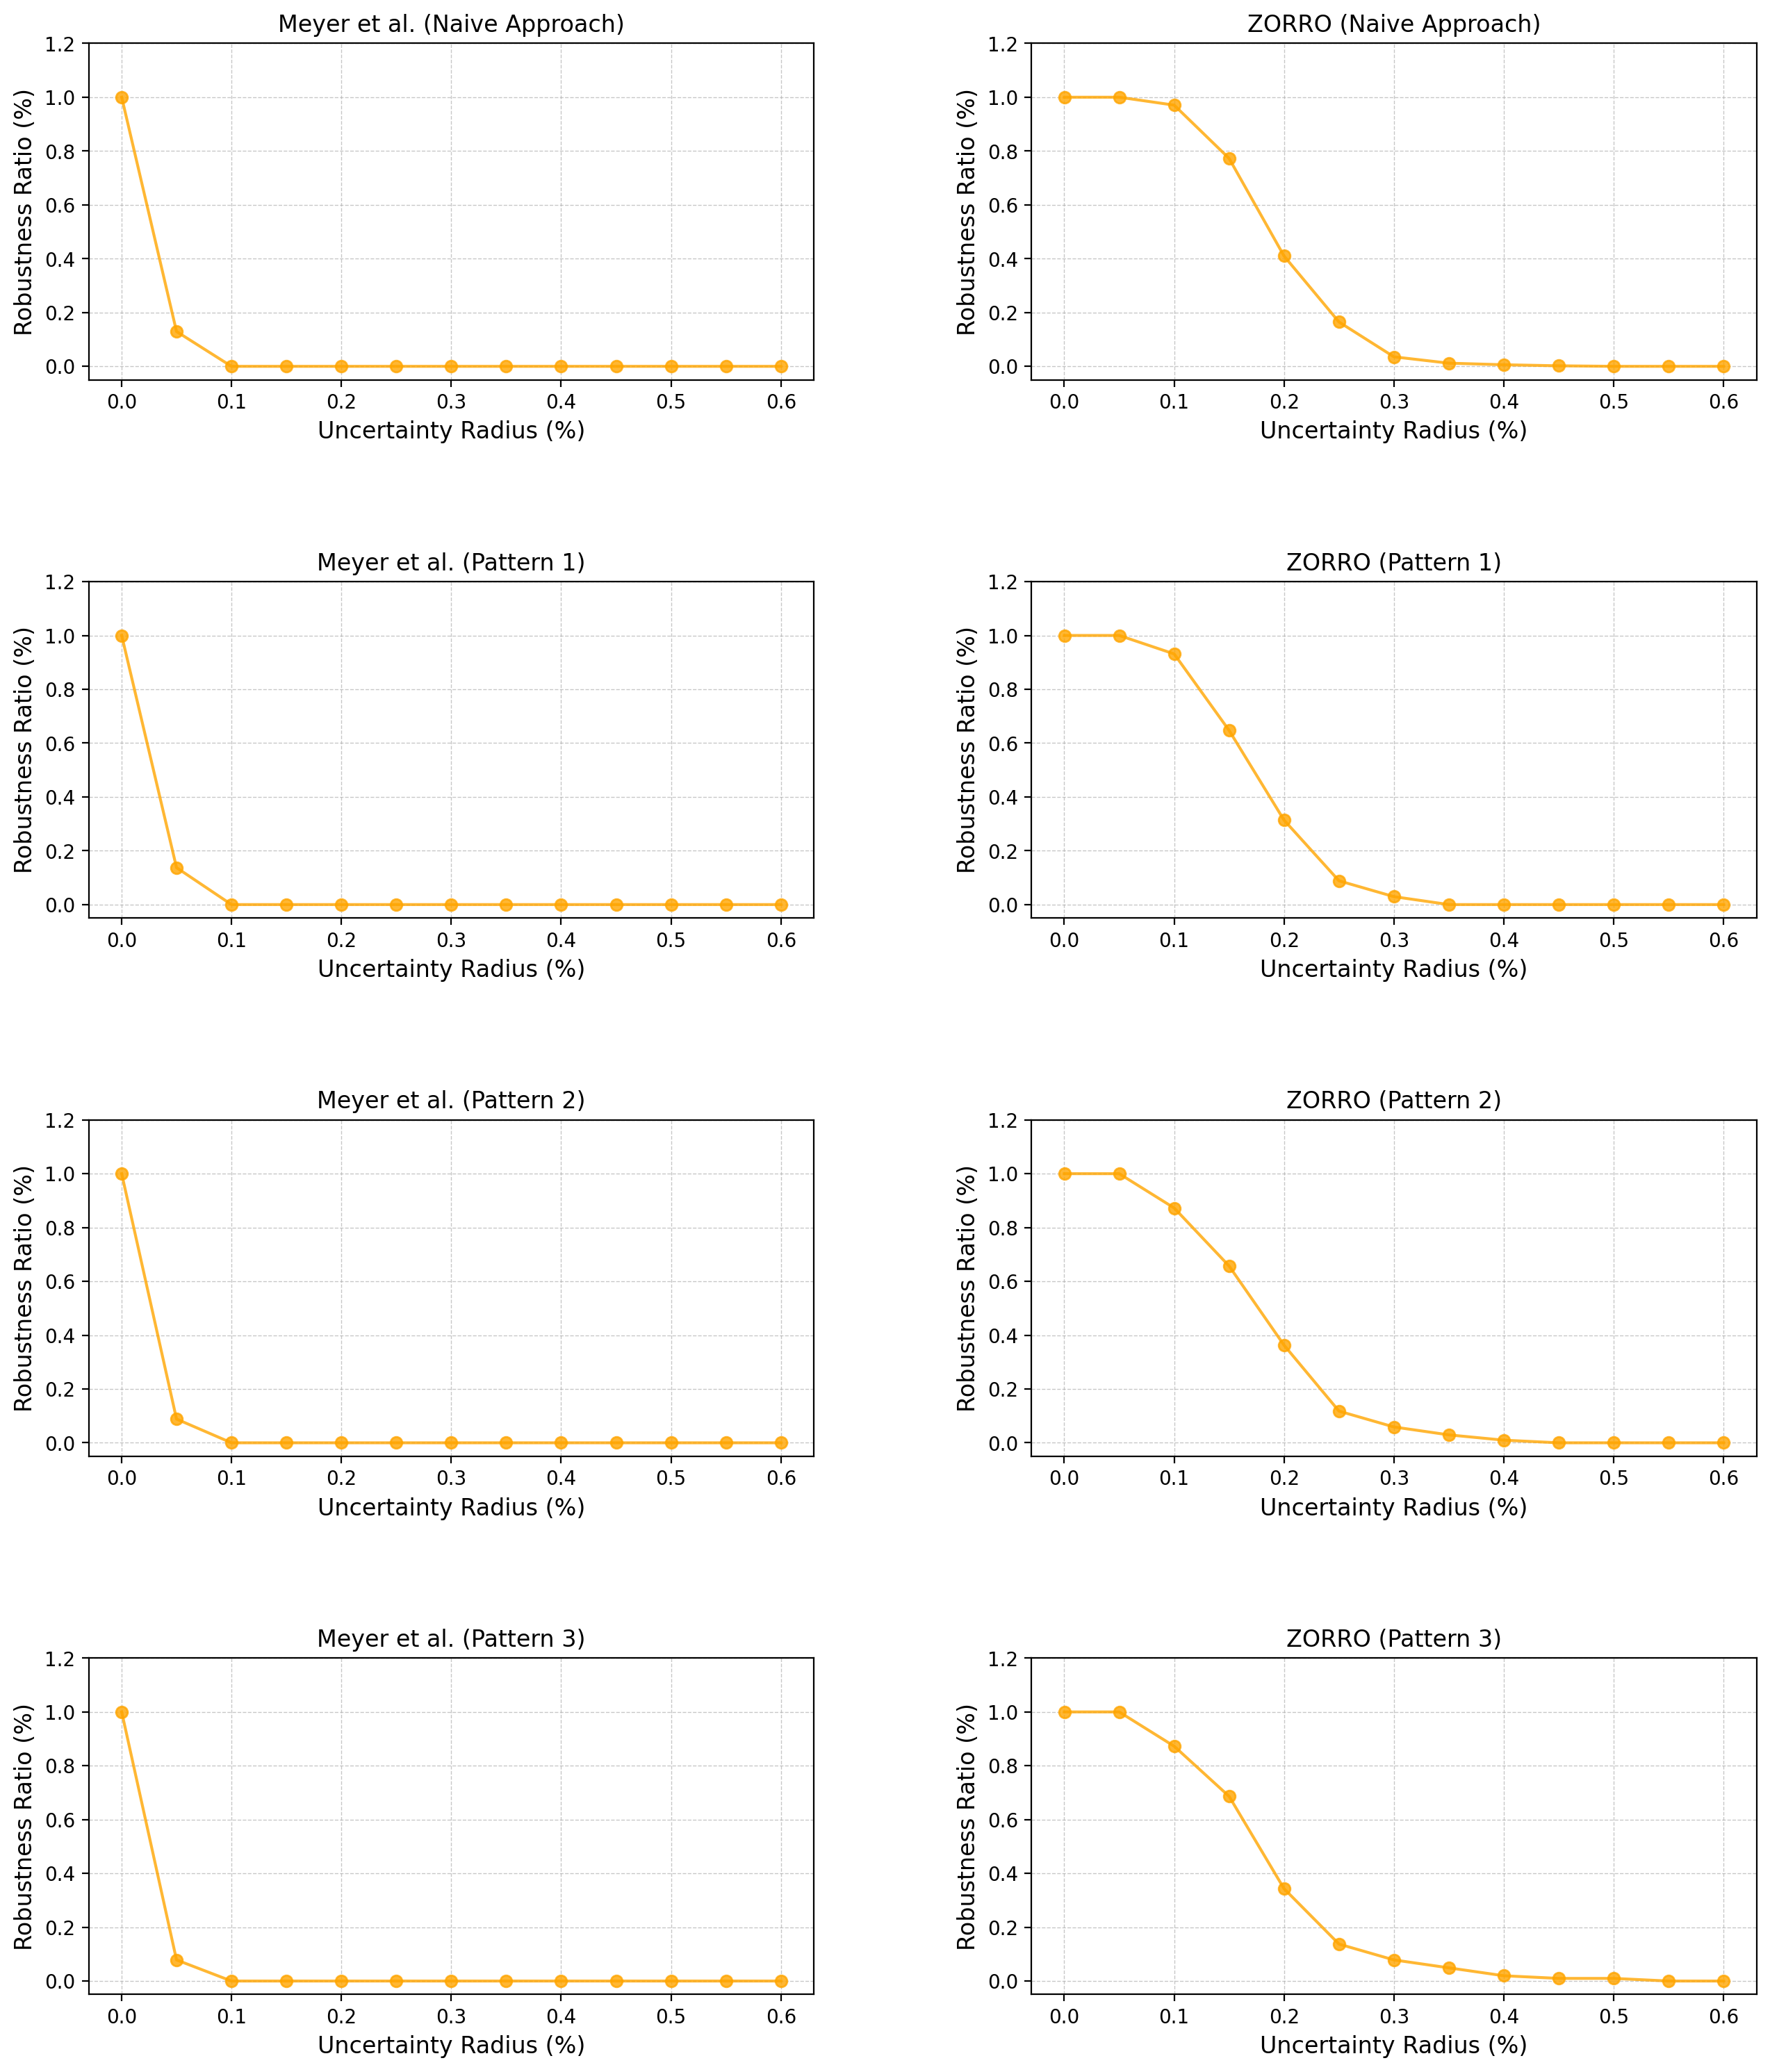

In [31]:
# Create the line plots with a 4x2 grid
fig, axes = plt.subplots(4, 2, figsize=(15, 18), dpi=200)

# Function to plot a single line plot with annotations
def plot_line(ax, x_values, y_values, title):
    ax.plot(x_values, y_values, marker='o', linestyle='-', color='orange', alpha=0.8, label='_nolegend_')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Uncertainty Radius (%)', fontsize=12)
    ax.set_ylabel('Robustness Ratio (%)', fontsize=12)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set(ylim = (-0.05, 1.2))
    
    # Add text annotations for each point with dynamic offset
    #y_offset = (max(y_values) - min(y_values)) * 0.05  # 5% of the y-range as offset
    #for x, y in zip(x_values, y_values):
    #    if y > 0:
    #        ax.text(x, y + y_offset, f'{y:.3f}', ha='center', va='bottom', fontsize=8)
    #    else:
    #        ax.text(x, y + y_offset * 2, f'{y:.3f}', ha='center', va='bottom', fontsize=8, color='gray')
    
    #ax.legend()

# Plot each line
plot_line(axes[0, 0], ratios, robustness_naive_interval, 'Meyer et al. (Naive Approach)')
plot_line(axes[0, 1], ratios, robustness_naive, 'ZORRO (Naive Approach)')
plot_line(axes[1, 0], ratios, robustness_ratio_range_pattern1_meyer, 'Meyer et al. (Pattern 1)')
plot_line(axes[1, 1], ratios, robustness_ratio_range_pattern1_zorro, 'ZORRO (Pattern 1)')
plot_line(axes[2, 0], ratios, robustness_ratio_range_pattern2_meyer, 'Meyer et al. (Pattern 2)')
plot_line(axes[2, 1], ratios, robustness_ratio_range_pattern2_zorro, 'ZORRO (Pattern 2)')
plot_line(axes[3, 0], ratios, robustness_ratio_range_pattern3_meyer, 'Meyer et al. (Pattern 3)')
plot_line(axes[3, 1], ratios, robustness_ratio_range_pattern3_zorro, 'ZORRO (Pattern 3)')

# Adjust layout
plt.subplots_adjust(wspace=0.3, hspace=0.6, bottom=0.1, left=0.1, right=0.9)

# Save the figure
plt.savefig('graph_outs/Robustness_decreasing_boston_lineplot_(Meyer and Zorro, 0.1).pdf', bbox_inches='tight')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


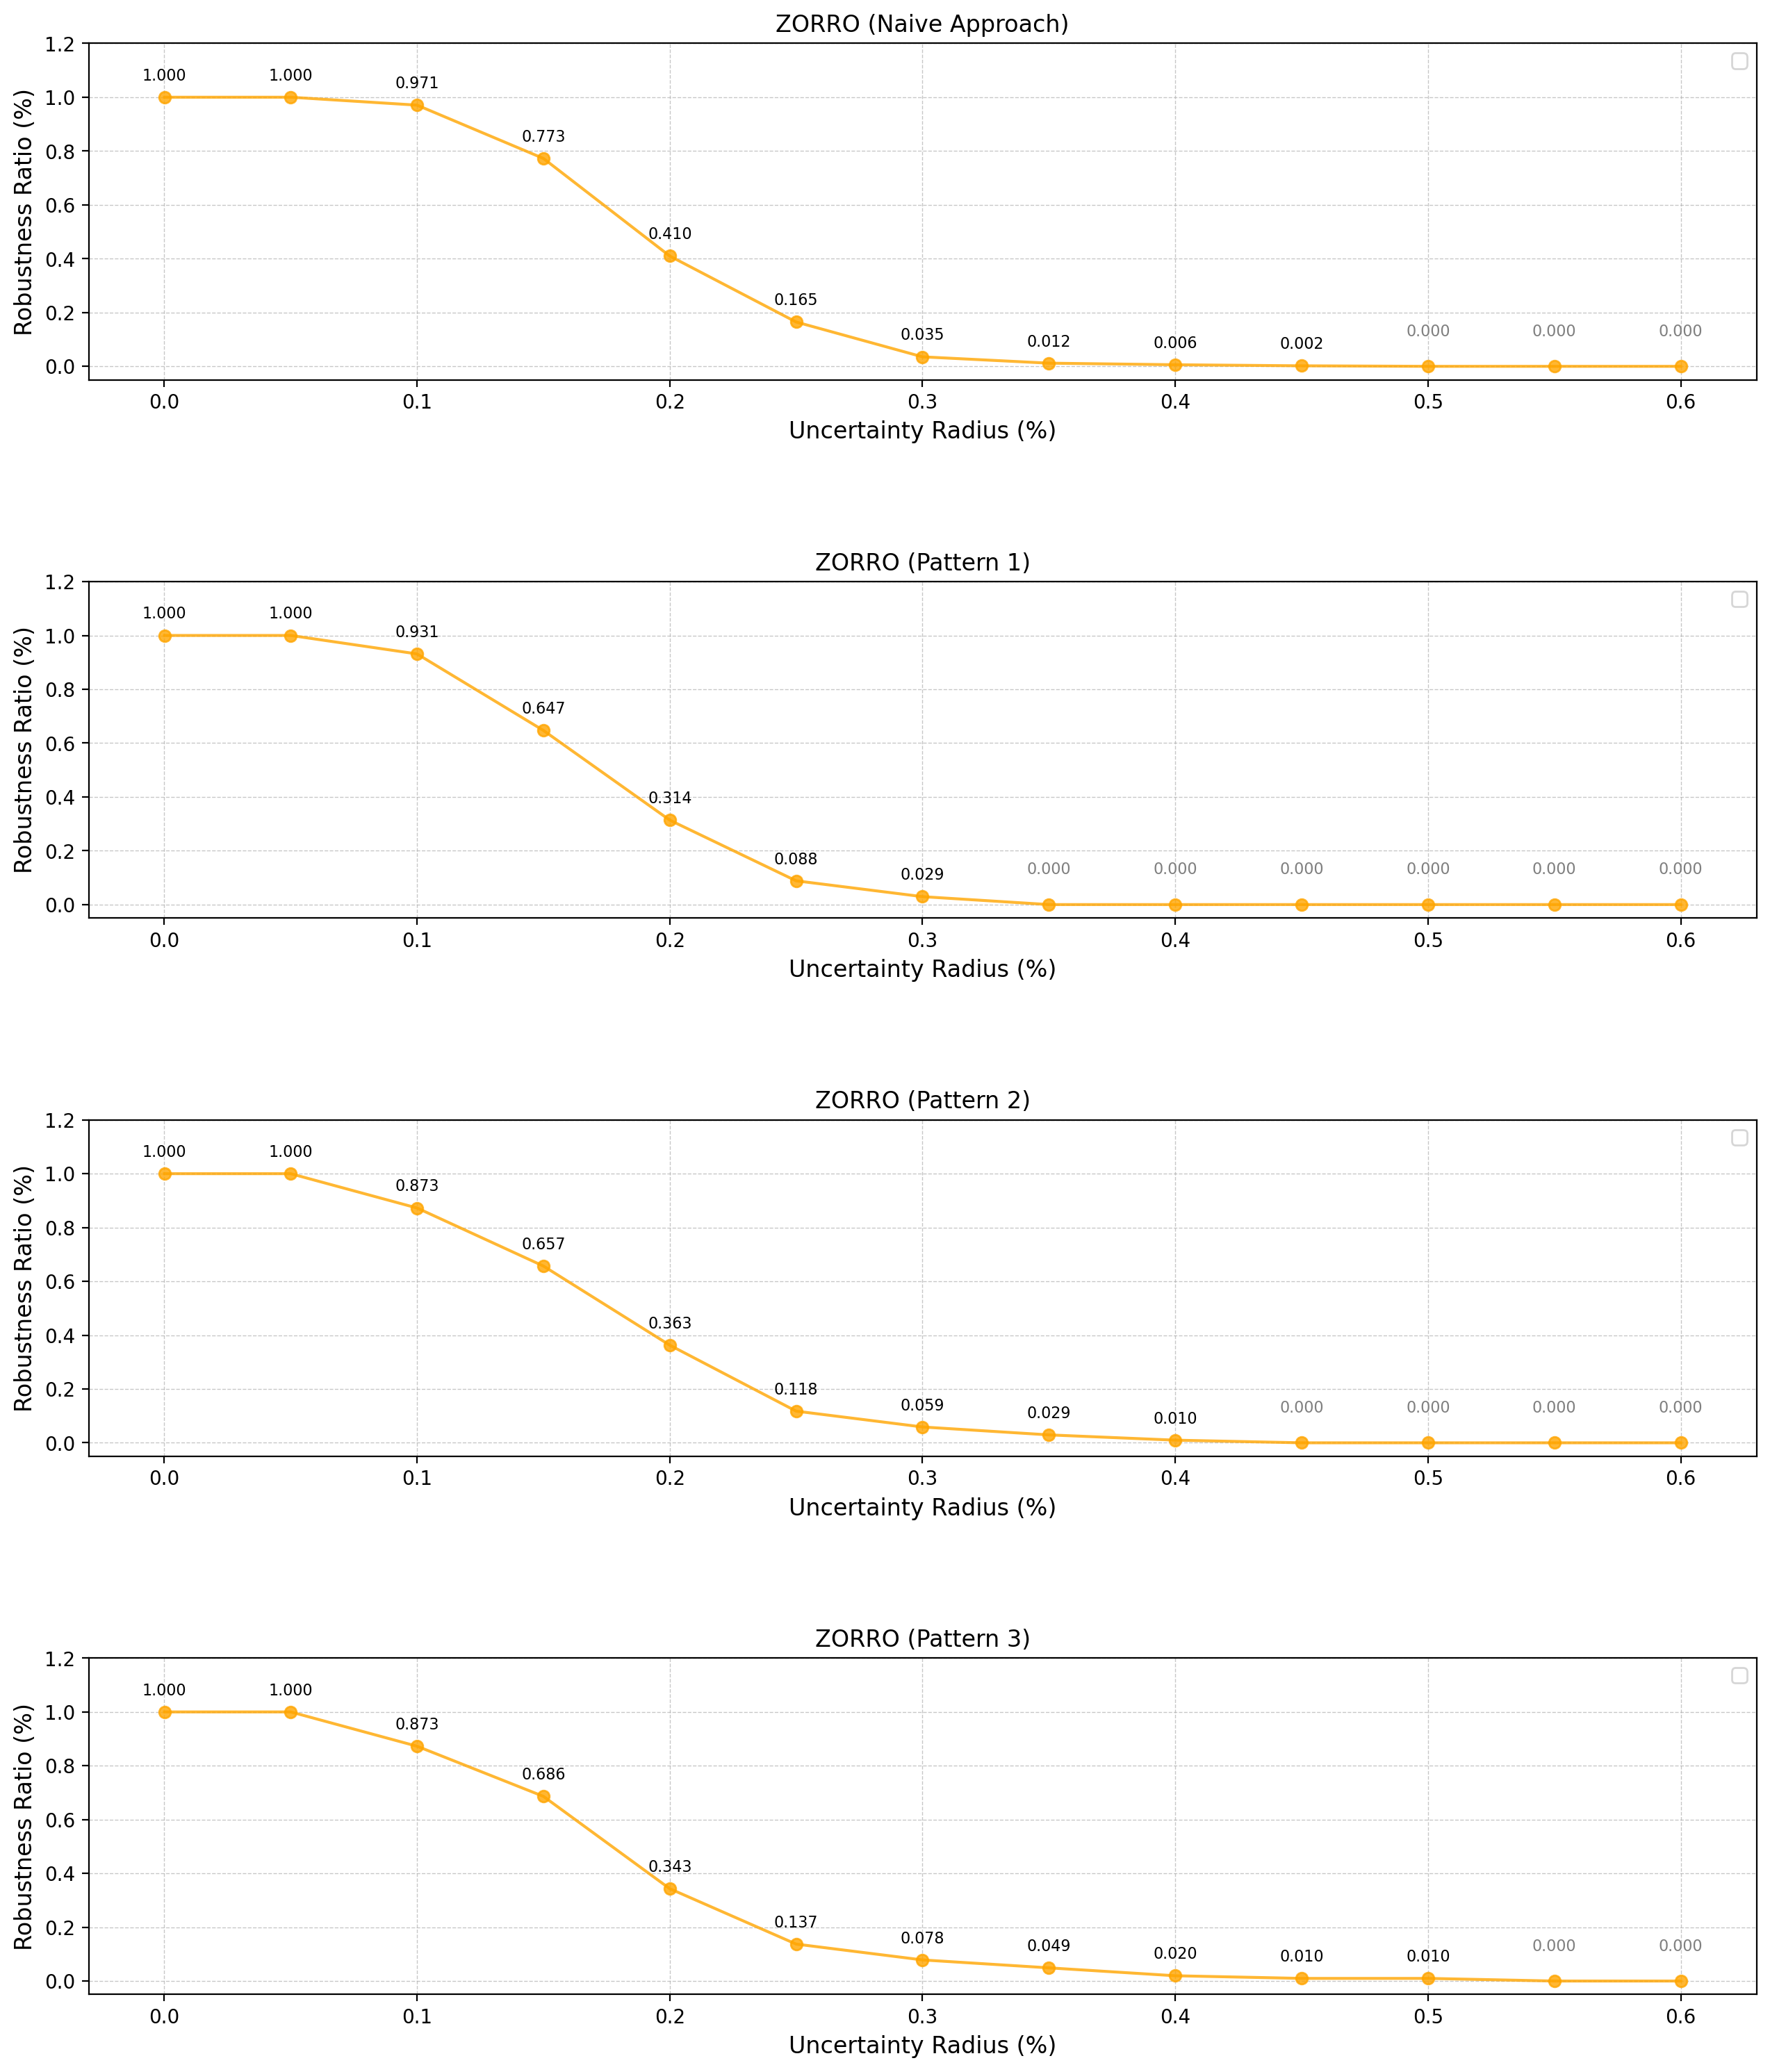

In [32]:
# Create the line plots with a 4x2 grid
fig, axes = plt.subplots(4, 1, figsize=(15, 18), dpi=200)
# Function to plot a single line plot with annotations
def plot_line(ax, x_values, y_values, title):
    ax.plot(x_values, y_values, marker='o', linestyle='-', color='orange', alpha=0.8, label='_nolegend_')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Uncertainty Radius (%)', fontsize=12)
    ax.set_ylabel('Robustness Ratio (%)', fontsize=12)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set(ylim = (-0.05, 1.2))
    
    # Add text annotations for each point with dynamic offset
    y_offset = (max(y_values) - min(y_values)) * 0.05  # 5% of the y-range as offset
    for x, y in zip(x_values, y_values):
        if y > 0:
            ax.text(x, y + y_offset, f'{y:.3f}', ha='center', va='bottom', fontsize=8)
        else:
            ax.text(x, y + y_offset * 2, f'{y:.3f}', ha='center', va='bottom', fontsize=8, color='gray')
    
    ax.legend()

# Plot each line
plot_line(axes[0], ratios, robustness_naive, 'ZORRO (Naive Approach)')
plot_line(axes[1], ratios, robustness_ratio_range_pattern1_zorro, 'ZORRO (Pattern 1)')
plot_line(axes[2], ratios, robustness_ratio_range_pattern2_zorro, 'ZORRO (Pattern 2)')
plot_line(axes[3], ratios, robustness_ratio_range_pattern3_zorro, 'ZORRO (Pattern 3)')

# Adjust layout
plt.subplots_adjust(wspace=0.3, hspace=0.6, bottom=0.1, left=0.1, right=0.9)

# Save the figure
plt.savefig('graph_outs/Robustness_decreasing_boston_lineplot_(Zorro w\ annotations, 0.1).pdf', bbox_inches='tight')